In [1]:
# get prop
import numpy as np
import requests
import matplotlib.pyplot as plt
import pandas as p
from IPython.display import display, HTML

#get data
from astroquery.mast import Observations
from astroquery.mast import Catalogs
from astropy.io import fits
from astropy import table
import matplotlib.pyplot as plt
import numpy as np
from copy import deepcopy
from corner import corner

%matplotlib inline

planeturl = "https://exo.mast.stsci.edu/api/v0.1/exoplanets/"
dvurl = "https://exo.mast.stsci.edu/api/v0.1/dvdata/tess/"
url = planeturl + "/identifiers/"
header={}

# mcmc
import pandas as pd
import seaborn as sb

from pathlib import Path
from uncertainties import ufloat
from scipy.stats import norm

from pytransit.lpf.tesslpf import TESSLPF, fold, downsample_time
from pytransit.orbits import epoch
from scipy.optimize import curve_fit

In [2]:
mcmc_repeats = 4

In [134]:
class fitransit:
    
    
    def __init__(self, planet_name: str, datadir = None, tic: int = None, zero_epoch: float = None, period: float = None, prop = None):
        
        if datadir == None:
            datadir = './data/' + planet_name.replace(' ','')
        myparams = {"name":planet_name}
        url = planeturl + "/identifiers/"
        r = requests.get(url = url, params = myparams, headers = header)
        # print(r.headers.get('content-type'))
        planet_names = r.json()
        self.ticid = planet_names['tessID']
        self.tce = planet_names['tessTCE']
        url = planeturl + planet_name + "/properties/"
        r = requests.get(url = url, headers = header)
        self.prop = r.json()
        self.planet_name = planet_name
        self.data_dir = datadir
        self.lpf = None
        self.period = self.prop[0]['orbital_period']
        self.transit_time = self.prop[0]['transit_time']
        self.tc = ufloat(self.transit_time,max(self.prop[0]['transit_time_lower'],self.prop[0]['transit_time_upper']))

    def get_parameters(self):
        
        return self.prop
        
    def print_parameters(self):

        planet_prop = self.prop
        print(self.planet_name + " Properties")
        print("Stellar Mass \t\t%f \t\t%s" % \
              (planet_prop[0]['Ms'], planet_prop[0]['Ms_unit'] ) )
        print("Planet Mass \t\t%f \t\t%s" % \
              (planet_prop[0]['Mp'], planet_prop[0]['Mp_unit'] ) )
        print("Planet Orbital Period \t%f \t\t%s" % \
              (planet_prop[0]['orbital_period'], \
               planet_prop[0]['orbital_period_unit'] ) )
        print("Transit Time \t\t%f \t\t%s" % \
              (planet_prop[0]['transit_time'] + 0.5, \
               planet_prop[0]['transit_time_unit'] ) )
        print("Planet Mass Reference: %s" % \
              (planet_prop[0]['Mp_ref']))
        
    def download_data(self):
        
        observations = Observations.query_object(self.planet_name,radius = "0 deg")
        obs_wanted = (observations['dataproduct_type'] \
                      == 'timeseries') & (observations['obs_collection'] == 'TESS')
        print( observations[obs_wanted]['obs_collection', 'project','obs_id'] )
        data_products = Observations.get_product_list(observations[obs_wanted])
        products_wanted = Observations.filter_products(data_products, 
                                            productSubGroupDescription=["DVT","LC"])

        print(products_wanted["productFilename"])
        manifest = Observations.download_products(products_wanted,download_dir=self.data_dir)
        print('\nfinished!')
        
    def set_lpf(self,data,modified_transit_time=None,modified_period=None):
        npop         = 30
        mcmc_repeats = 4
        datadir = data

        planet_prop = self.prop
        transit_time = planet_prop[0]['transit_time'] + 2.4e6 + 0.5
        transit_time_err = max(planet_prop[0]['transit_time_lower'],planet_prop[0]['transit_time_upper'])
        orbital_period = planet_prop[0]['orbital_period']
        orbital_period_err = max(planet_prop[0]['orbital_period_lower'],planet_prop[0]['orbital_period_upper'])

        if modified_transit_time == None:
            zero_epoch = ufloat(transit_time,transit_time_err)
        else:
            zero_epoch = ufloat(modified_transit_time,transit_time_err)
        if modified_period == None:
            period = ufloat(orbital_period,orbital_period_err)
        else:
            period = ufloat(modified_period,orbital_period_err)
            
        self.tc = zero_epoch
    
    
        self.lpf = TESSLPF(self.planet_name,datadir,tic=self.ticid,zero_epoch=zero_epoch.n,period=period.n,use_pdc=True,nsamples=2, bldur=0.25)
        
    
        ep = epoch(self.lpf.times[0].mean(), self.lpf.zero_epoch, self.lpf.period)
        tc = zero_epoch + ep*period

        self.lpf.set_prior('tc', 'NP', tc.n,     0.005)          # Wide normal prior on the transit center
        self.lpf.set_prior('p',  'NP', period.n, period.s)  # Wide normal prior on the orbital period
        self.lpf.set_prior('rho', 'UP', 0, 1)               # Uniform prior on the stellar density
        self.lpf.set_prior('k2', 'UP', 0.0, 0.2**2)             # Uniform prior on the area ratio
        self.lpf.set_prior('gp_ln_in', 'UP', -2, 1)             # Uniform prior on the GP input scale
        self.lpf.optimize_global(200, npop=npop)
        
    def mcmc(self):
        self.lpf.sample_mcmc(2500, thin=25, repeats=mcmc_repeats)
    
    def corner_plot(self,nrows=5,ncols=5,figsize=(6.5,6.5)):
        
        fig,ax = plt.subplots(nrows,ncols,figsize)
        df = self.lpf.posterior_samples()
        corner(df['tc p rho b k'.split()],
        labels='\n\n\nZero epoch, \n\n\nPeriod, \n\n\nStellar density, \n\n\nimpact parameter, \n\n\nradius ratio'.split(', '),fig=fig,show_titles=True)
        plt.subplots_adjust(wspace=0.2,hspace=0.2)
        return fig

# WASP-44 b

In [57]:
wasp44b = fitransit("WASP-44 b")

In [58]:
wasp44b.print_parameters()
# wasp44b.download_data()

WASP-44 b Properties
Stellar Mass 		0.951000 		M_sun
Planet Mass 		0.889836 		M_Jupiter
Planet Orbital Period 	2.423804 		d
Transit Time 		55434.376000 		MJD
Planet Mass Reference: Calculated from MSINI and I


Global optimisation:   0%|          | 0/200 [00:00<?, ?it/s]

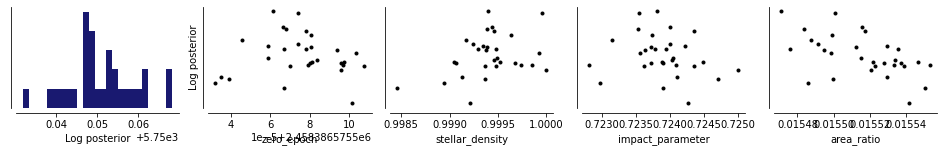

In [59]:
wasp44b.set_lpf('./data/WASP-44b/mastDownload/TESS/tess2018263035959-s0003-0000000012862099-0123-s/')

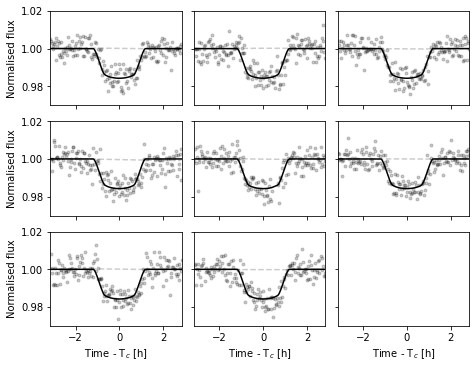

In [182]:
fig = wasp44b.lpf.plot_individual_transits(figsize=(6.5,5),ncols=3,ylim=(0.97,1.02))
fig.savefig('./image/wasp44b_individual_tansits.pdf')

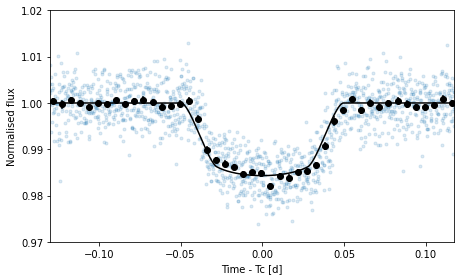

In [183]:
fig = wasp44b.lpf.plot_folded_transit(figsize=(6.5,4),ylim=(0.97, 1.02))
fig.savefig('./image/wasp44b_folded_tansit.pdf')

In [166]:
wasp44b.mcmc()

MCMC sampling:   0%|          | 0/4 [00:00<?, ?it/s]

Run 1/4:   0%|          | 0/2500 [00:00<?, ?it/s]

Run 2/4:   0%|          | 0/2500 [00:00<?, ?it/s]

Run 3/4:   0%|          | 0/2500 [00:00<?, ?it/s]

Run 4/4:   0%|          | 0/2500 [00:00<?, ?it/s]

In [72]:
wasp44b.lpf.print_parameters(columns=1)

  0 |G| tc             N(μ = 2458386.5691502, σ = 0.0006)       [    -inf ..      inf]
  1 |G| p              N(μ = 2.4238039000000002, σ = 8.7e-06)   [    0.00 ..      inf]
  2 |G| rho            U(a = 0, b = 1)                          [    0.00 ..      inf]
  3 |G| b              U(a = 0.0, b = 1.0)                      [    0.00 ..     1.00]
  4 |P| k2             U(a = 0.0, b = 0.04000000000000001)      [    0.00 ..      inf]
  5 |P| q1_TESS        U(a = 0, b = 1)                          [    0.00 ..     1.00]
  6 |P| q2_TESS        U(a = 0, b = 1)                          [    0.00 ..     1.00]
  7 |L| gp_ln_out      N(μ = -6.0, σ = 1.5)                     [    -inf ..      inf]
  8 |L| gp_ln_in       U(a = -2, b = 1)                         [    -inf ..      inf]
  9 |L| gp_log10_wn    N(μ = -2.378200919186614, σ = 0.025)     [    -inf ..      inf]


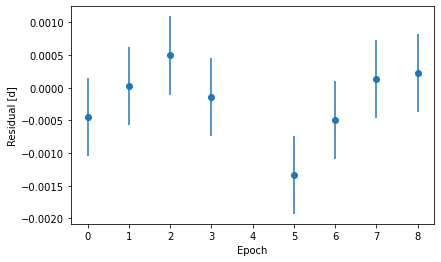

In [207]:
lpf = wasp44b.lpf

ep = epoch(lpf.times[0].mean(), lpf.zero_epoch, lpf.period)
mean_v = np.vectorize(np.mean)

tcs = mean_v(lpf.times)
tcs_err = np.ones((1,len(tcs)))[0] * 6e-4

epoch_v = np.vectorize(epoch)
epochs = epoch_v(tcs,lpf.zero_epoch, lpf.period)

# tcs = np.insert(tcs,0,wasp44b.lpf.zero_epoch)
# epochs = np.insert(epochs,0,0)
re = tcs - epochs * lpf.period - lpf.zero_epoch
e = epochs - epochs[0]

y = lambda x,a,b: a*np.sin(x) + b
rlt = curve_fit(y,e,re)



x = np.linspace(0,e[-1],100)
# tcs - epochs * lpf.period - tcs[0]
# plt.plot(x,rlt[0][0]*np.sin(x)+rlt[0][1],c='k')
fig,ax = plt.subplots(figsize=(6.5,4))
plt.scatter(e,re)
plt.errorbar(e,re,yerr=tcs_err,linestyle=' ')
plt.xlabel("Epoch")
plt.ylabel("Residual [d]")
plt.savefig("image/wasp44b_ttv.pdf",bbox_inches='tight')

In [77]:
tcs_err

array([[0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006]])

In [1]:
lpf = wasp44b.lpf

ep = epoch(lpf.times[0].mean(), lpf.zero_epoch, lpf.period)
mean_v = np.vectorize(np.mean)

tcs = mean_v(lpf.times)
tcs_err = np.ones((1,len(tcs)))[0] * 6e-4

epoch_v = np.vectorize(epoch)
epochs = epoch_v(tcs,lpf.zero_epoch, lpf.period)

# tcs = np.insert(tcs,0,wasp44b.lpf.zero_epoch)
# epochs = np.insert(epochs,0,0)
re = tcs - epochs * lpf.period - lpf.zero_epoch
e = epochs - epochs[0]

y = lambda x,a,b: a*np.sin(x) + b
rlt = curve_fit(y,e,re)



x = np.linspace(0,e[-1],100)
# tcs - epochs * lpf.period - tcs[0]
fig,ax = plt.subplots(figsize=(6.5,4))
plt.plot(x,rlt[0][0]*np.sin(x)+rlt[0][1],c='k',label='fitted by sin')
plt.scatter(e,re)
plt.errorbar(e,re,yerr=tcs_err,linestyle=' ')
plt.xlabel("Epoch")
plt.ylabel("Residual [d]")
plt.legend()
plt.savefig("image/wasp44b_ttv_fit.pdf",bbox_inches='tight')

NameError: name 'wasp44b' is not defined

In [153]:
tc = wasp44b.transit_time + ep*wasp44b.lpf.period

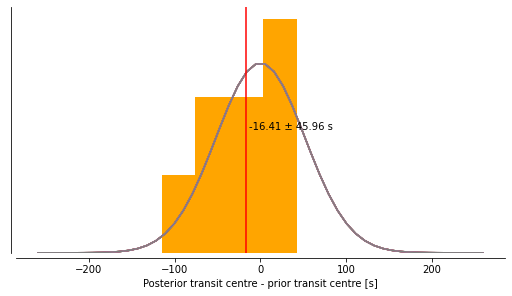

In [117]:
fig, ax = plt.subplots(figsize=(7,4), constrained_layout=True)
d_to_s = 24*60*60
tc_diff = d_to_s*(re)
tc_diff_m = np.mean(tc_diff)
x = np.linspace(- 5*tcs_err, 5*tcs_err)
ax.plot(d_to_s*x, norm(0, d_to_s*tcs_err).pdf(d_to_s*x));
ax.hist(tc_diff, density=True, bins='auto',color='orange')
ax.axvline(tc_diff_m,c='r')
ax.annotate(f'{tc_diff_m:.2f} ± {tc_diff.std():.2f} s', (tc_diff_m, 0.005), ((tc_diff_m+3, 0.005)))
plt.setp(ax, xlabel='Posterior transit centre - prior transit centre [s]', yticks=[])
sb.despine(fig, offset=5)

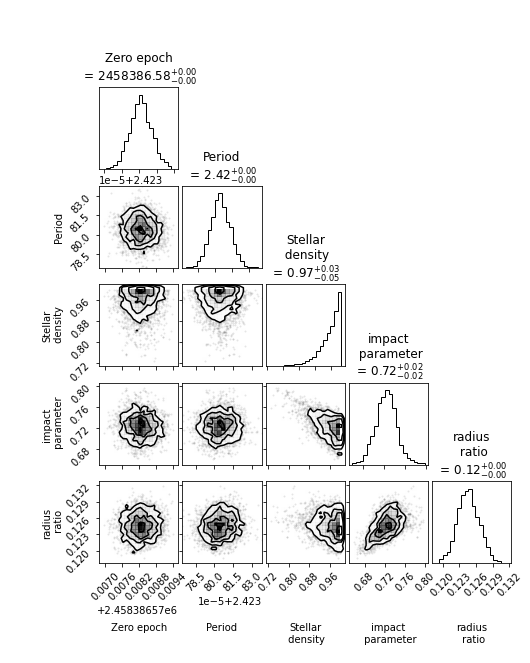

In [80]:
fig,ax = plt.subplots(5,5,figsize=(6.5,7.5))
df = wasp44b.lpf.posterior_samples()
corner(df['tc p rho b k'.split()],
labels='\n\n\nZero epoch\n, \n\n\nPeriod\n, \n\n\nStellar\n density\n, \n\n\nimpact\n parameter\n, \n\n\nradius\n ratio\n'.split(', '),fig=fig,show_titles=True)
fig.subplots_adjust(hspace=0.2)
# fig.tight_layout(h_pad=5)
fig.savefig('image/wasp44b_mcmc.pdf',bbox_inches='tight')

# WASP-11 b

In [138]:
wasp11b = fitransit("WASP-11 b")
wasp11b.print_parameters()
# wasp11b.download_data()

WASP-11 b Properties
Stellar Mass 		0.800000 		M_sun
Planet Mass 		0.539755 		M_Jupiter
Planet Orbital Period 	3.722465 		d
Transit Time 		54473.055880 		MJD
Planet Mass Reference: Calculated from MSINI and I


Global optimisation:   0%|          | 0/200 [00:00<?, ?it/s]

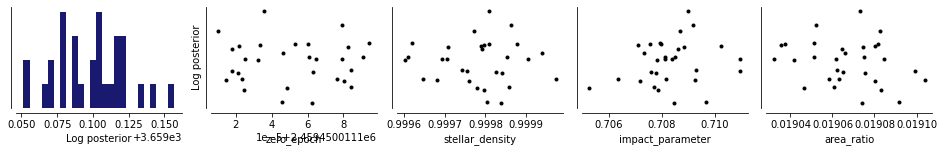

In [139]:
wasp11b.set_lpf('./data/WASP-11b/mastDownload/TESS/tess2021232031932-s0042-0000000085593751-0213-s/')

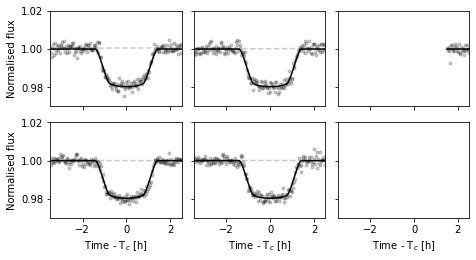

In [140]:
fig = wasp11b.lpf.plot_individual_transits(figsize=(6.5,3.5),ncols=3,ylim=(0.97,1.02))
fig.savefig('./image/wasp11b_individual_tansits.pdf')

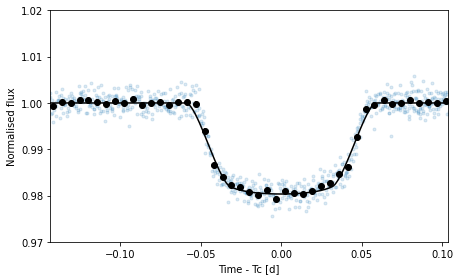

In [141]:
fig = wasp11b.lpf.plot_folded_transit(figsize=(6.5,4),ylim=(0.97, 1.02))
fig.savefig('./image/wasp11b_folded_tansit.pdf')

In [60]:
wasp11b.mcmc()

MCMC sampling:   0%|          | 0/4 [00:00<?, ?it/s]

Run 1/4:   0%|          | 0/2500 [00:00<?, ?it/s]

Run 2/4:   0%|          | 0/2500 [00:00<?, ?it/s]

Run 3/4:   0%|          | 0/2500 [00:00<?, ?it/s]

Run 4/4:   0%|          | 0/2500 [00:00<?, ?it/s]

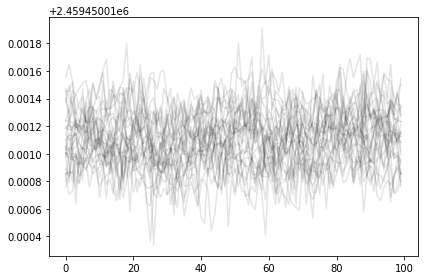

In [91]:
fig = wasp11b.lpf.plot_mcmc_chains()

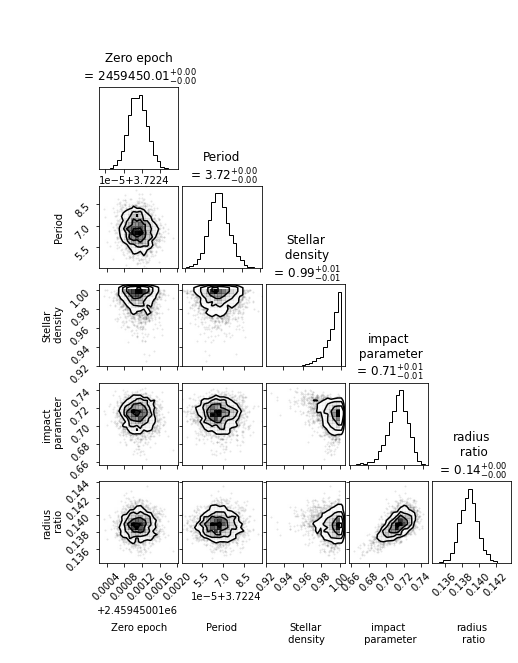

In [79]:
fig,ax = plt.subplots(5,5,figsize=(6.5,7.5))
df = wasp11b.lpf.posterior_samples()
corner(df['tc p rho b k'.split()],
labels='\n\n\nZero epoch\n, \n\n\nPeriod\n, \n\n\nStellar\n density\n, \n\n\nimpact\n parameter\n, \n\n\nradius\n ratio\n'.split(', '),fig=fig,show_titles=True)
fig.subplots_adjust(hspace=0.2)
# fig.tight_layout(h_pad=5)
fig.savefig('image/wasp11b_mcmc.pdf',bbox_inches='tight')

In [142]:
wasp11b.lpf.print_parameters(columns=1)

  0 |G| tc             N(μ = 2459449.991585, σ = 0.005)         [    -inf ..      inf]
  1 |G| p              N(μ = 3.722465, σ = 8e-06)               [    0.00 ..      inf]
  2 |G| rho            U(a = 0, b = 1)                          [    0.00 ..      inf]
  3 |G| b              U(a = 0.0, b = 1.0)                      [    0.00 ..     1.00]
  4 |P| k2             U(a = 0.0, b = 0.04000000000000001)      [    0.00 ..      inf]
  5 |P| q1_TESS        U(a = 0, b = 1)                          [    0.00 ..     1.00]
  6 |P| q2_TESS        U(a = 0, b = 1)                          [    0.00 ..     1.00]
  7 |L| gp_ln_out      N(μ = -6.0, σ = 1.5)                     [    -inf ..      inf]
  8 |L| gp_ln_in       U(a = -2, b = 1)                         [    -inf ..      inf]
  9 |L| gp_log10_wn    N(μ = -2.7519708259876468, σ = 0.025)    [    -inf ..      inf]


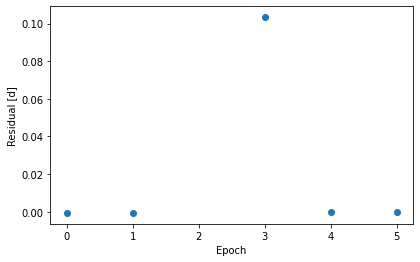

In [215]:
lpf = wasp11b.lpf

ep = epoch(lpf.times[0].mean(), lpf.zero_epoch, lpf.period)
mean_v = np.vectorize(np.mean)

tcs = mean_v(lpf.times)
tcs_err = np.ones((1,len(tcs)))[0] * 6e-4

epoch_v = np.vectorize(epoch)
epochs = epoch_v(tcs,lpf.zero_epoch, lpf.period)

# tcs = np.insert(tcs,0,wasp44b.lpf.zero_epoch)
# epochs = np.insert(epochs,0,0)
re = tcs - epochs * lpf.period - lpf.zero_epoch
e = epochs - epochs[0]

y = lambda x,a,b: a*np.sin(x) + b
rlt = curve_fit(y,e,re)

# re = np.delete(re, 2)
# e = np.delete(e, 2)
# tcs_err = np.delete(tcs_err, 2)


x = np.linspace(0,e[-1],100)
# tcs - epochs * lpf.period - tcs[0]
# plt.plot(x,rlt[0][0]*np.sin(x)+rlt[0][1],c='k')
fig,ax = plt.subplots(figsize=(6.5,4))
plt.scatter(e,re)
plt.errorbar(e,re,yerr=tcs_err,linestyle=' ')
plt.xlabel("Epoch")
plt.ylabel("Residual [d]") 
plt.savefig("image/wasp11b_ttv.pdf",bbox_inches='tight')

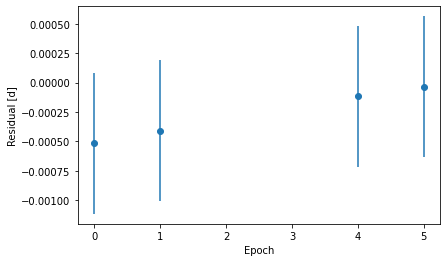

In [216]:
lpf = wasp11b.lpf

ep = epoch(lpf.times[0].mean(), lpf.zero_epoch, lpf.period)
mean_v = np.vectorize(np.mean)

tcs = mean_v(lpf.times)
tcs_err = np.ones((1,len(tcs)))[0] * 6e-4

epoch_v = np.vectorize(epoch)
epochs = epoch_v(tcs,lpf.zero_epoch, lpf.period)

# tcs = np.insert(tcs,0,wasp44b.lpf.zero_epoch)
# epochs = np.insert(epochs,0,0)
re = tcs - epochs * lpf.period - lpf.zero_epoch
e = epochs - epochs[0]

y = lambda x,a,b: a*np.sin(x) + b
rlt = curve_fit(y,e,re)

re = np.delete(re, 2)
e = np.delete(e, 2)
tcs_err = np.delete(tcs_err, 2)


x = np.linspace(0,e[-1],100)
# tcs - epochs * lpf.period - tcs[0]
# plt.plot(x,rlt[0][0]*np.sin(x)+rlt[0][1],c='k')
fig,ax = plt.subplots(figsize=(6.5,4))
plt.scatter(e,re)
plt.errorbar(e,re,yerr=tcs_err,linestyle=' ')
plt.xlabel("Epoch")
plt.ylabel("Residual [d]") 
plt.savefig("image/wasp11b_ttv_modified.pdf",bbox_inches='tight')

# WASP-18 b

In [218]:
wasp18b = fitransit("WASP-18 b")
wasp18b.print_parameters()
# wasp18b.download_data()

WASP-18 b Properties
Stellar Mass 		1.220000 		M_sun
Planet Mass 		10.200600 		M_Jupiter
Planet Orbital Period 	0.941453 		d
Transit Time 		54664.905310 		MJD
Planet Mass Reference: Calculated from MSINI and I


Global optimisation:   0%|          | 0/200 [00:00<?, ?it/s]

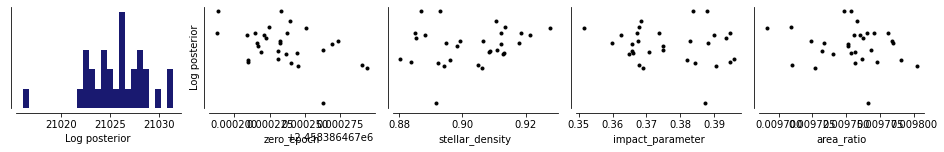

In [219]:
wasp18b.set_lpf('./data/WASP-18b/mastDownload/TESS/tess2018263035959-s0003-0000000100100827-0123-s')

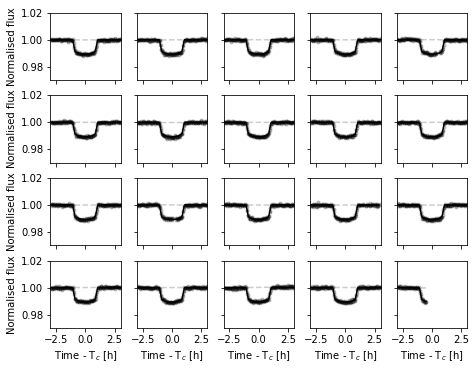

In [220]:
fig = wasp18b.lpf.plot_individual_transits(figsize=(6.5,5),ncols=5,ylim=(0.97,1.02))
fig.savefig('./image/wasp18b_individual_tansits.pdf')

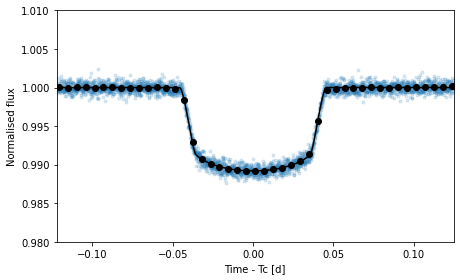

In [221]:
fig = wasp18b.lpf.plot_folded_transit(figsize=(6.5,4),ylim=(0.98, 1.01))
fig.savefig('./image/wasp18b_folded_tansit.pdf')

In [43]:
wasp18b.mcmc()

MCMC sampling:   0%|          | 0/4 [00:00<?, ?it/s]

Run 1/4:   0%|          | 0/2500 [00:00<?, ?it/s]

Run 2/4:   0%|          | 0/2500 [00:00<?, ?it/s]

Run 3/4:   0%|          | 0/2500 [00:00<?, ?it/s]

Run 4/4:   0%|          | 0/2500 [00:00<?, ?it/s]

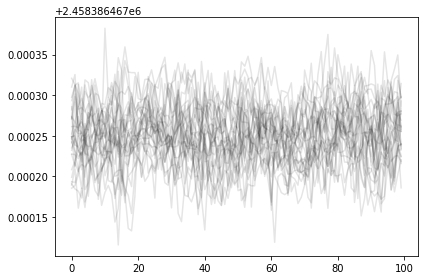

In [92]:
fig = wasp18b.lpf.plot_mcmc_chains()

In [222]:
wasp18b.lpf.print_parameters(columns=1)

  0 |G| tc             N(μ = 2458386.4686236996, σ = 0.005)     [    -inf ..      inf]
  1 |G| p              N(μ = 0.9414529, σ = 8.599999999999998e-07) [    0.00 ..      inf]
  2 |G| rho            U(a = 0, b = 1)                          [    0.00 ..      inf]
  3 |G| b              U(a = 0.0, b = 1.0)                      [    0.00 ..     1.00]
  4 |P| k2             U(a = 0.0, b = 0.04000000000000001)      [    0.00 ..      inf]
  5 |P| q1_TESS        U(a = 0, b = 1)                          [    0.00 ..     1.00]
  6 |P| q2_TESS        U(a = 0, b = 1)                          [    0.00 ..     1.00]
  7 |L| gp_ln_out      N(μ = -6.0, σ = 1.5)                     [    -inf ..      inf]
  8 |L| gp_ln_in       U(a = -2, b = 1)                         [    -inf ..      inf]
  9 |L| gp_log10_wn    N(μ = -3.2512444607405895, σ = 0.025)    [    -inf ..      inf]


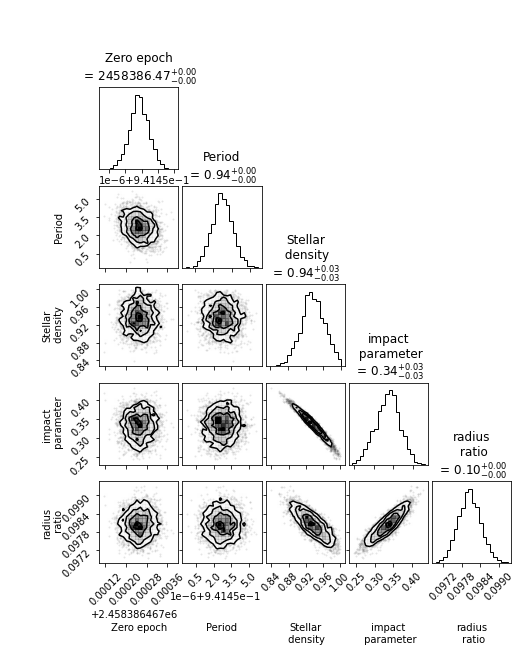

In [82]:
fig,ax = plt.subplots(5,5,figsize=(6.5,7.5))
df = wasp18b.lpf.posterior_samples()
corner(df['tc p rho b k'.split()],
labels='\n\n\nZero epoch\n, \n\n\nPeriod\n, \n\n\nStellar\n density\n, \n\n\nimpact\n parameter\n, \n\n\nradius\n ratio\n'.split(', '),fig=fig,show_titles=True)
fig.subplots_adjust(hspace=0.2)
# fig.tight_layout(h_pad=5)
fig.savefig('image/wasp18b_mcmc.pdf',bbox_inches='tight')

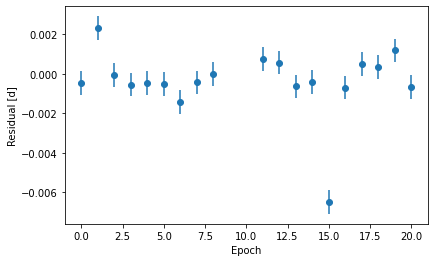

In [232]:
lpf = wasp18b.lpf

ep = epoch(lpf.times[0].mean(), lpf.zero_epoch, lpf.period)
mean_v = np.vectorize(np.mean)

tcs = mean_v(lpf.times)
tcs_err = np.ones((1,len(tcs)))[0] * 6e-4

epoch_v = np.vectorize(epoch)
epochs = epoch_v(tcs,lpf.zero_epoch, lpf.period)

# tcs = np.insert(tcs,0,wasp44b.lpf.zero_epoch)
# epochs = np.insert(epochs,0,0)
re = tcs - epochs * lpf.period - lpf.zero_epoch
e = epochs - epochs[0]

y = lambda x,a,b: a*np.sin(x) + b
rlt = curve_fit(y,e,re)

re = np.delete(re, -1)
e = np.delete(e, -1)
tcs_err = np.delete(tcs_err, -1)


x = np.linspace(0,e[-1],100)
# tcs - epochs * lpf.period - tcs[0]
# plt.plot(x,rlt[0][0]*np.sin(x)+rlt[0][1],c='k')
fig,ax = plt.subplots(figsize=(6.5,4))
plt.scatter(e,re)
plt.errorbar(e,re,yerr=tcs_err,linestyle=' ')
plt.xlabel("Epoch")
plt.ylabel("Residual [d]") 
plt.savefig("image/wasp18b_ttv_modified.pdf",bbox_inches='tight')

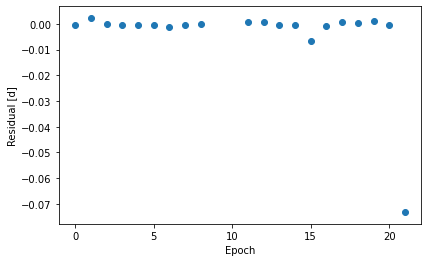

In [231]:
lpf = wasp18b.lpf

ep = epoch(lpf.times[0].mean(), lpf.zero_epoch, lpf.period)
mean_v = np.vectorize(np.mean)

tcs = mean_v(lpf.times)
tcs_err = np.ones((1,len(tcs)))[0] * 6e-4

epoch_v = np.vectorize(epoch)
epochs = epoch_v(tcs,lpf.zero_epoch, lpf.period)

# tcs = np.insert(tcs,0,wasp44b.lpf.zero_epoch)
# epochs = np.insert(epochs,0,0)
re = tcs - epochs * lpf.period - lpf.zero_epoch
e = epochs - epochs[0]



# re = np.delete(re, [-1, -7, 1])
# e = np.delete(e, [-1, -7, 1])
# tcs_err = np.delete(tcs_err, [-1, -7, 1])

y = lambda x,a,b: a*np.sin(x) + b
rlt = curve_fit(y,e,re)

x = np.linspace(0,e[-1],100)
# tcs - epochs * lpf.period - tcs[0]

fig,ax = plt.subplots(figsize=(6.5,4))
plt.scatter(e,re)
plt.errorbar(e,re,yerr=tcs_err,linestyle=' ')
# plt.plot(x,rlt[0][0]*np.sin(x)+rlt[0][1],c='k')
plt.xlabel("Epoch")
plt.ylabel("Residual [d]") 
plt.savefig("image/wasp18b_ttv.pdf",bbox_inches='tight')

# WASP-120 b

In [234]:
wasp120b = fitransit("WASP-120 b")
wasp120b.print_parameters()
# wasp120b.download_data()

WASP-120 b Properties
Stellar Mass 		1.390000 		M_sun
Planet Mass 		4.850000 		M_Jupiter
Planet Orbital Period 	3.611271 		d
Transit Time 		56779.435560 		MJD
Planet Mass Reference: Turner et al. 2016


Global optimisation:   0%|          | 0/200 [00:00<?, ?it/s]

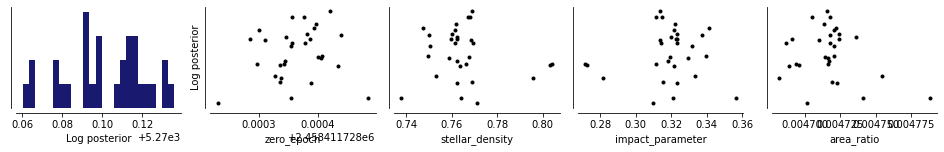

In [235]:
wasp120b.set_lpf('./data/WASP-120b/mastDownload/TESS/tess2018292075959-s0004-0000000152476657-0124-s',2456779.43556)

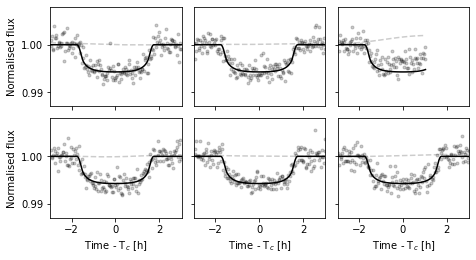

In [236]:
fig = wasp120b.lpf.plot_individual_transits(figsize=(6.5,3.5),ncols=3,ylim=(0.987,1.008))
fig.savefig('./image/wasp120b_individual_tansits.pdf')

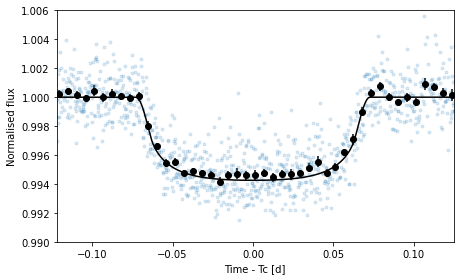

In [48]:
fig = wasp120b.lpf.plot_folded_transit(figsize=(6.5,4),ylim=(0.99, 1.006))
fig.savefig('./image/wasp120b_folded_tansit.pdf')

In [49]:
wasp120b.mcmc()

MCMC sampling:   0%|          | 0/4 [00:00<?, ?it/s]

Run 1/4:   0%|          | 0/2500 [00:00<?, ?it/s]

Run 2/4:   0%|          | 0/2500 [00:00<?, ?it/s]

Run 3/4:   0%|          | 0/2500 [00:00<?, ?it/s]

Run 4/4:   0%|          | 0/2500 [00:00<?, ?it/s]

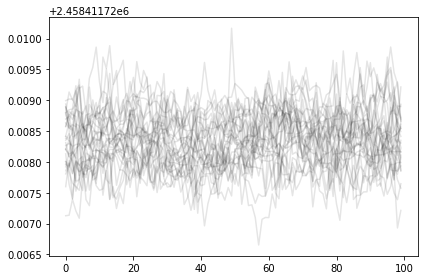

In [94]:
fig = wasp120b.lpf.plot_mcmc_chains()

In [132]:
wasp120b.lpf.print_parameters(columns=1)

  0 |G| tc             N(μ = 2458411.7298712, σ = 0.005)        [    -inf ..      inf]
  1 |G| p              N(μ = 3.6112706, σ = 4.3e-06)            [    0.00 ..      inf]
  2 |G| rho            U(a = 0, b = 1)                          [    0.00 ..      inf]
  3 |G| b              U(a = 0.0, b = 1.0)                      [    0.00 ..     1.00]
  4 |P| k2             U(a = 0.0, b = 0.04000000000000001)      [    0.00 ..      inf]
  5 |P| q1_TESS        U(a = 0, b = 1)                          [    0.00 ..     1.00]
  6 |P| q2_TESS        U(a = 0, b = 1)                          [    0.00 ..     1.00]
  7 |L| gp_ln_out      N(μ = -6.0, σ = 1.5)                     [    -inf ..      inf]
  8 |L| gp_ln_in       U(a = -2, b = 1)                         [    -inf ..      inf]
  9 |L| gp_log10_wn    N(μ = -2.8548750561959024, σ = 0.025)    [    -inf ..      inf]


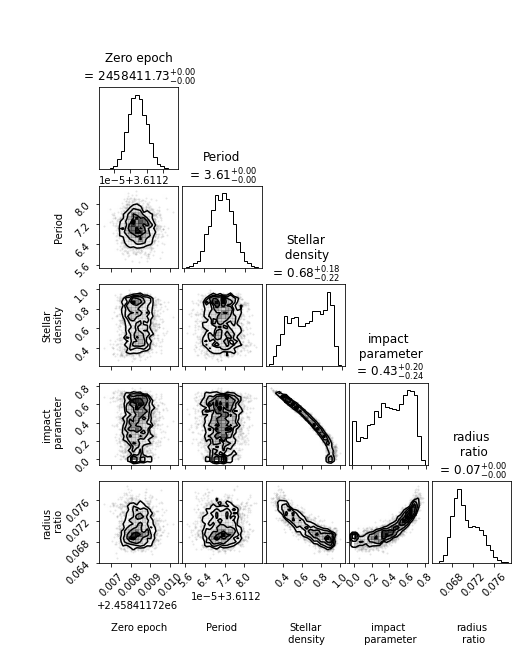

In [81]:
fig,ax = plt.subplots(5,5,figsize=(6.5,7.5))
df = wasp120b.lpf.posterior_samples()
corner(df['tc p rho b k'.split()],
labels='\n\n\nZero epoch\n, \n\n\nPeriod\n, \n\n\nStellar\n density\n, \n\n\nimpact\n parameter\n, \n\n\nradius\n ratio\n'.split(', '),fig=fig,show_titles=True)
fig.subplots_adjust(hspace=0.2)
# fig.tight_layout(h_pad=5)
fig.savefig('image/wasp120b_mcmc.pdf',bbox_inches='tight')

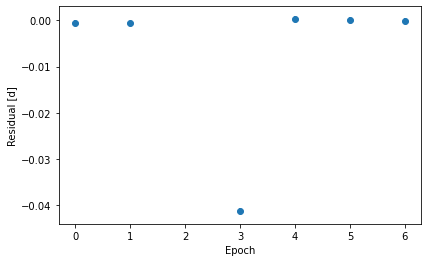

In [237]:
lpf = wasp120b.lpf

ep = epoch(lpf.times[0].mean(), lpf.zero_epoch, lpf.period)
mean_v = np.vectorize(np.mean)

tcs = mean_v(lpf.times)
tcs_err = np.ones((1,len(tcs)))[0] * 6e-4

epoch_v = np.vectorize(epoch)
epochs = epoch_v(tcs,lpf.zero_epoch, lpf.period)

# tcs = np.insert(tcs,0,wasp44b.lpf.zero_epoch)
# epochs = np.insert(epochs,0,0)
re = tcs - epochs * lpf.period - lpf.zero_epoch
e = epochs - epochs[0]



# re = np.delete(re, [-1, -7, 1])
# e = np.delete(e, [-1, -7, 1])
# tcs_err = np.delete(tcs_err, [-1, -7, 1])

y = lambda x,a,b: a*np.sin(x) + b
rlt = curve_fit(y,e,re)

x = np.linspace(0,e[-1],100)
# tcs - epochs * lpf.period - tcs[0]

fig,ax = plt.subplots(figsize=(6.5,4))
plt.scatter(e,re)
plt.errorbar(e,re,yerr=tcs_err,linestyle=' ')
# plt.plot(x,rlt[0][0]*np.sin(x)+rlt[0][1],c='k')
plt.xlabel("Epoch")
plt.ylabel("Residual [d]") 
plt.savefig("image/wasp120b_ttv.pdf",bbox_inches='tight')

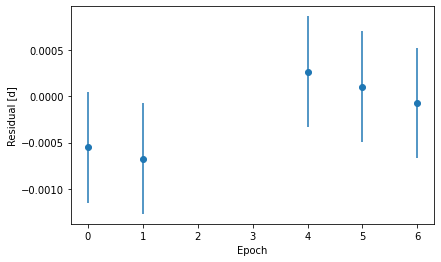

In [238]:
lpf = wasp120b.lpf

ep = epoch(lpf.times[0].mean(), lpf.zero_epoch, lpf.period)
mean_v = np.vectorize(np.mean)

tcs = mean_v(lpf.times)
tcs_err = np.ones((1,len(tcs)))[0] * 6e-4

epoch_v = np.vectorize(epoch)
epochs = epoch_v(tcs,lpf.zero_epoch, lpf.period)

# tcs = np.insert(tcs,0,wasp44b.lpf.zero_epoch)
# epochs = np.insert(epochs,0,0)
re = tcs - epochs * lpf.period - lpf.zero_epoch
e = epochs - epochs[0]



re = np.delete(re, 2)
e = np.delete(e, 2)
tcs_err = np.delete(tcs_err, 2)

y = lambda x,a,b: a*np.sin(x) + b
rlt = curve_fit(y,e,re)

x = np.linspace(0,e[-1],100)
# tcs - epochs * lpf.period - tcs[0]

fig,ax = plt.subplots(figsize=(6.5,4))
plt.scatter(e,re)
plt.errorbar(e,re,yerr=tcs_err,linestyle=' ')
# plt.plot(x,rlt[0][0]*np.sin(x)+rlt[0][1],c='k')
plt.xlabel("Epoch")
plt.ylabel("Residual [d]") 
plt.savefig("image/wasp120b_ttv_modified.pdf",bbox_inches='tight')

# WASP-32 b

In [242]:
wasp32b = fitransit("WASP-32 b")
wasp32b.print_parameters()
# wasp32b.download_data()

WASP-32 b Properties
Stellar Mass 		1.070000 		M_sun
Planet Mass 		3.453620 		M_Jupiter
Planet Orbital Period 	2.718661 		d
Transit Time 		55681.194500 		MJD
Planet Mass Reference: Calculated from MSINI and I


Global optimisation:   0%|          | 0/200 [00:00<?, ?it/s]

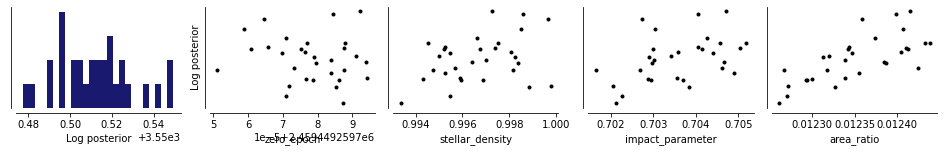

In [243]:
wasp32b.set_lpf('./data/WASP-32b/mastDownload/TESS/tess2021232031932-s0042-0000000427332229-0213-s')

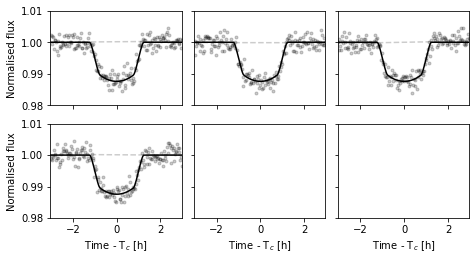

In [244]:
fig = wasp32b.lpf.plot_individual_transits(figsize=(6.5,3.5),ncols=3,ylim=(0.98, 1.01))
fig.savefig('./image/wasp32b_individual_tansits.pdf')

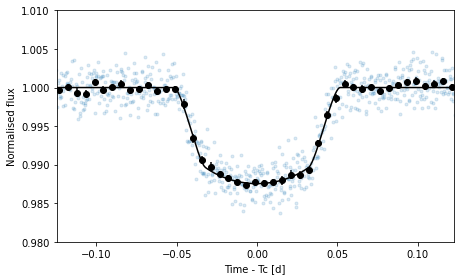

In [151]:
fig = wasp32b.lpf.plot_folded_transit(figsize=(6.5,4),ylim=(0.98, 1.01))
fig.savefig('./image/wasp32b_folded_tansit.pdf')

In [55]:
wasp32b.mcmc()

MCMC sampling:   0%|          | 0/4 [00:00<?, ?it/s]

Run 1/4:   0%|          | 0/2500 [00:00<?, ?it/s]

Run 2/4:   0%|          | 0/2500 [00:00<?, ?it/s]

Run 3/4:   0%|          | 0/2500 [00:00<?, ?it/s]

Run 4/4:   0%|          | 0/2500 [00:00<?, ?it/s]

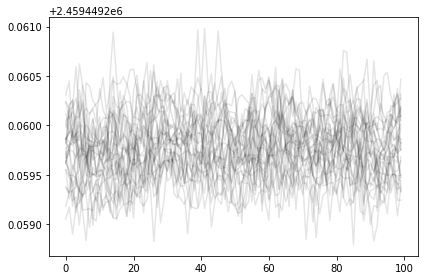

In [95]:
fig = wasp32b.lpf.plot_mcmc_chains()

In [158]:
wasp32b.lpf.print_parameters(columns=1)

  0 |G| tc             N(μ = 2459449.258646, σ = 0.005)         [    -inf ..      inf]
  1 |G| p              N(μ = 2.718661, σ = 2e-06)               [    0.00 ..      inf]
  2 |G| rho            U(a = 0, b = 1)                          [    0.00 ..      inf]
  3 |G| b              U(a = 0.0, b = 1.0)                      [    0.00 ..     1.00]
  4 |P| k2             U(a = 0.0, b = 0.04000000000000001)      [    0.00 ..      inf]
  5 |P| q1_TESS        U(a = 0, b = 1)                          [    0.00 ..     1.00]
  6 |P| q2_TESS        U(a = 0, b = 1)                          [    0.00 ..     1.00]
  7 |L| gp_ln_out      N(μ = -6.0, σ = 1.5)                     [    -inf ..      inf]
  8 |L| gp_ln_in       U(a = -2, b = 1)                         [    -inf ..      inf]
  9 |L| gp_log10_wn    N(μ = -2.749786770277868, σ = 0.025)     [    -inf ..      inf]


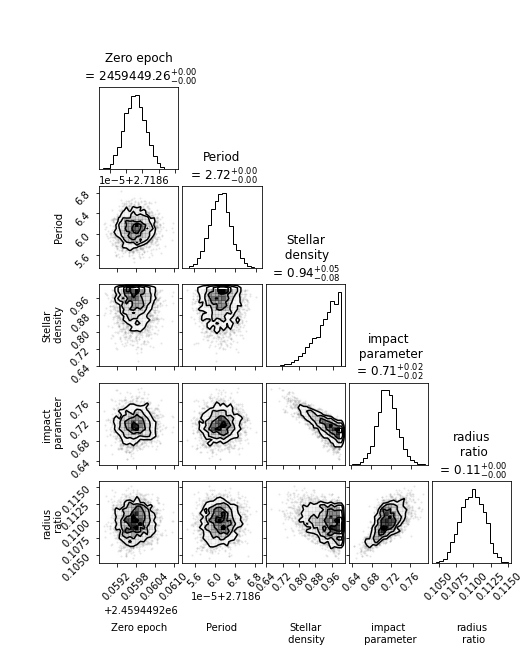

In [74]:
fig,ax = plt.subplots(5,5,figsize=(6.5,7.5))
df = wasp32b.lpf.posterior_samples()
corner(df['tc p rho b k'.split()],
labels='\n\n\nZero epoch\n, \n\n\nPeriod\n, \n\n\nStellar\n density\n, \n\n\nimpact\n parameter\n, \n\n\nradius\n ratio\n'.split(', '),fig=fig,show_titles=True)
fig.subplots_adjust(hspace=0.2)
# fig.tight_layout(h_pad=5)
fig.savefig('image/wasp32b_mcmc.pdf',bbox_inches='tight')

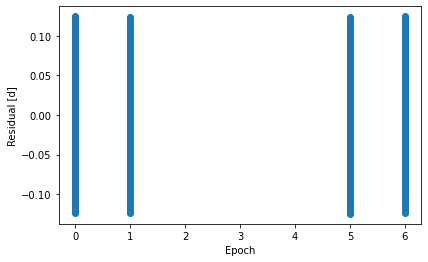

In [248]:
lpf = wasp32b.lpf

ep = epoch(lpf.times[0].mean(), lpf.zero_epoch, lpf.period)
mean_v = np.vectorize(np.mean)

tcs = mean_v(lpf.times)
tcs_err = np.ones((1,len(tcs)))[0] * 6e-4

epoch_v = np.vectorize(epoch)
epochs = epoch_v(tcs,lpf.zero_epoch, lpf.period)

# tcs = np.insert(tcs,0,wasp44b.lpf.zero_epoch)
# epochs = np.insert(epochs,0,0)
re = tcs - epochs * lpf.period - lpf.zero_epoch
e = epochs - epochs[0]



# re = np.delete(re, [-1, -7, 1])
# e = np.delete(e, [-1, -7, 1])
# tcs_err = np.delete(tcs_err, [-1, -7, 1])

y = lambda x,a,b: a*np.sin(x) + b
# rlt = curve_fit(y,e,re)

x = np.linspace(0,e[-1],100)
# tcs - epochs * lpf.period - tcs[0]

fig,ax = plt.subplots(figsize=(6.5,4))
plt.scatter(e,re)
# plt.errorbar(e,re,yerr=tcs_err,linestyle=' ')
# plt.plot(x,rlt[0][0]*np.sin(x)+rlt[0][1],c='k')
plt.xlabel("Epoch")
plt.ylabel("Residual [d]") 
plt.savefig("image/wasp32b_ttv.pdf",bbox_inches='tight')

ValueError: The lengths of the data (719) and the error 3 do not match

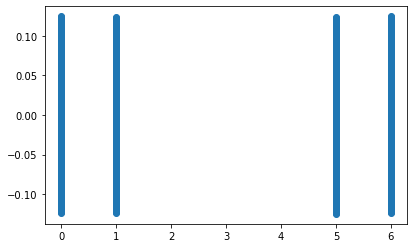

In [246]:
lpf = wasp32b.lpf

ep = epoch(lpf.times[0].mean(), lpf.zero_epoch, lpf.period)
mean_v = np.vectorize(np.mean)

tcs = mean_v(lpf.times)
tcs_err = np.ones((1,len(tcs)))[0] * 6e-4

epoch_v = np.vectorize(epoch)
epochs = epoch_v(tcs,lpf.zero_epoch, lpf.period)

# tcs = np.insert(tcs,0,wasp44b.lpf.zero_epoch)
# epochs = np.insert(epochs,0,0)
re = tcs - epochs * lpf.period - lpf.zero_epoch
e = epochs - epochs[0]



re = np.delete(re, 2)
e = np.delete(e, 2)
tcs_err = np.delete(tcs_err, 2)

y = lambda x,a,b: a*np.sin(x) + b
rlt = curve_fit(y,e,re)

x = np.linspace(0,e[-1],100)
# tcs - epochs * lpf.period - tcs[0]

fig,ax = plt.subplots(figsize=(6.5,4))
plt.scatter(e,re)
plt.errorbar(e,re,yerr=tcs_err,linestyle=' ')
# plt.plot(x,rlt[0][0]*np.sin(x)+rlt[0][1],c='k')
plt.xlabel("Epoch")
plt.ylabel("Residual [d]") 
plt.savefig("image/wasp32b_ttv_modified.pdf",bbox_inches='tight')